In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
dados = pd.read_csv(url, sep=';')

In [4]:
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [6]:
round(dados['Valor'].mean(), 2)

np.float64(12952.66)

In [ ]:
round(dados.groupby('Tipo')['Valor'].mean(numeric_only=True), 2)

In [ ]:
round(dados.groupby('Tipo')[['Valor']].mean(numeric_only=True), 2).sort_values('Valor')

<Axes: ylabel='Tipo'>

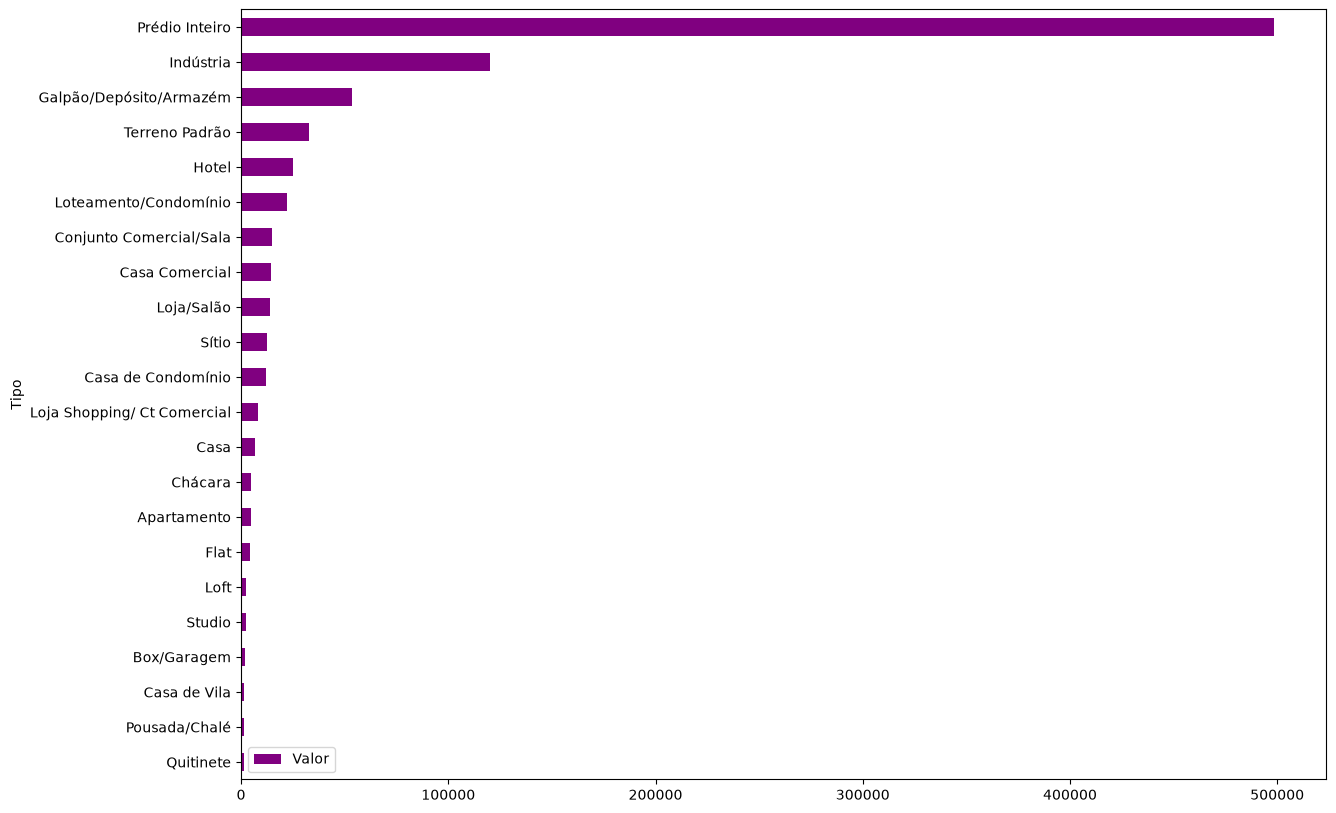

In [20]:
df_preco_tipo = round(dados.groupby('Tipo')[['Valor']].mean(numeric_only=True), 2).sort_values('Valor')

df_preco_tipo.plot(kind='barh', figsize=(14,10), color='purple')

In [30]:
dados.Tipo.unique()

<StringArray>
[                  'Quitinete',                        'Casa',
     'Conjunto Comercial/Sala',                 'Apartamento',
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              'Terreno Padrão',
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']
Length: 22, dtype: str

In [36]:
imoveis_comerciais = [                                          'Casa',
     'Conjunto Comercial/Sala',                 
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']

In [37]:
dados.query('@imoveis_comerciais in Tipo')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
7,Casa de Condomínio,Barra da Tijuca,5,4,5,750,22000.0,NaN,NaN
8,Casa de Condomínio,Ramos,2,2,0,65,1000.0,NaN,NaN
9,Conjunto Comercial/Sala,Centro,0,3,0,695,35000.0,19193.0,3030.0
...,...,...,...,...,...,...,...,...,...
32946,Conjunto Comercial/Sala,Centro,0,0,0,140,4000.0,1412.0,496.0
32948,Conjunto Comercial/Sala,Centro,0,0,0,32,600.0,1035.0,83.0
32952,Casa de Condomínio,Barra da Tijuca,5,3,4,450,15000.0,1711.0,2332.0
32954,Box/Garagem,Centro,0,0,0,755,14000.0,NaN,NaN


In [38]:
df = dados.query(f'{imoveis_comerciais} not in Tipo')

In [40]:
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0


In [39]:
df.Tipo.unique()

<StringArray>
['Quitinete', 'Apartamento', 'Terreno Padrão']
Length: 3, dtype: str

In [41]:
df.Tipo.value_counts()

Tipo
Apartamento       19532
Quitinete           836
Terreno Padrão       70
Name: count, dtype: int64

<Axes: xlabel='Percentual', ylabel='Tipos'>

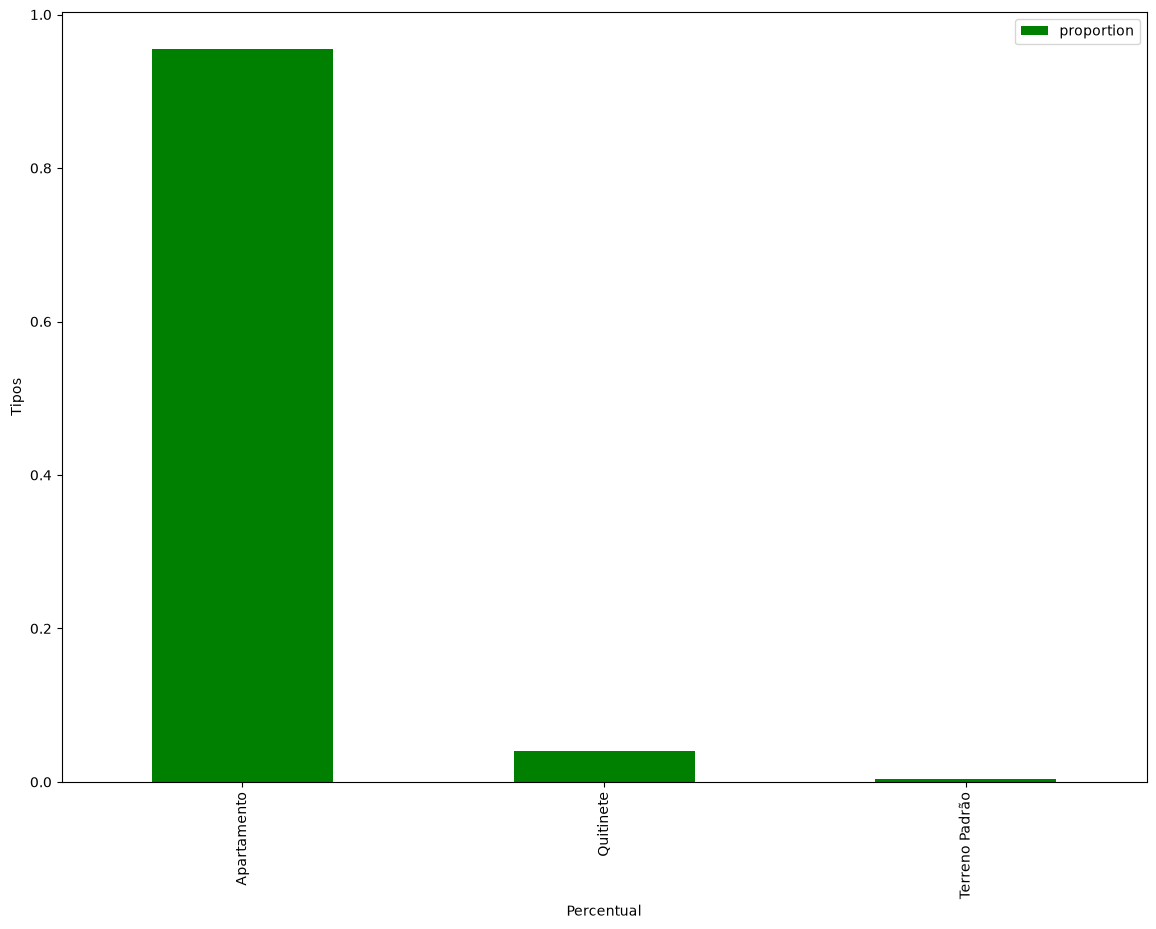

In [46]:
df_percentual_tipo = df.Tipo.value_counts(normalize=True).to_frame().sort_values('Tipo')

df_percentual_tipo.plot(kind='bar', figsize=(14,10), color='green', ylabel='Tipos', xlabel='Percentual')

In [49]:
df = df.query('Tipo == "Apartamento"')

In [51]:
df.fillna(0).head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,0.0,0.0
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,0.0,0.0


atividade

In [52]:
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [57]:
round(dados.groupby('Tipo')['Quartos'].mean())

Tipo
Apartamento                     2.0
Box/Garagem                     0.0
Casa                            3.0
Casa Comercial                  2.0
Casa de Condomínio              4.0
Casa de Vila                    2.0
Chácara                         3.0
Conjunto Comercial/Sala         0.0
Flat                            1.0
Galpão/Depósito/Armazém         0.0
Hotel                          26.0
Indústria                       0.0
Loft                            1.0
Loja Shopping/ Ct Comercial     0.0
Loja/Salão                      0.0
Loteamento/Condomínio           0.0
Pousada/Chalé                  23.0
Prédio Inteiro                  0.0
Quitinete                       1.0
Studio                          0.0
Sítio                           5.0
Terreno Padrão                  0.0
Name: Quartos, dtype: float64

In [58]:
# 2

dados['Bairro'].unique()

<StringArray>
[         'Copacabana',     'Jardim Botânico',     'Barra da Tijuca',
              'Centro',        'Higienópolis',        'Vista Alegre',
            'Cachambi',               'Ramos',              'Grajaú',
 'Lins de Vasconcelos',
 ...
      'Cidade de Deus',    'Magalhães Bastos',         'Coelho Neto',
       'Vasco da Gama',           'Bancários',        'Rio da Prata',
       'Cidade Jardim',     'Parque Colúmbia',             'Grumari',
            'Sepetiba']
Length: 162, dtype: str

In [63]:
# 3

media_valor = round(dados['Valor'].mean())

dados[dados['Valor'] > media_valor]

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
7,Casa de Condomínio,Barra da Tijuca,5,4,5,750,22000.0,NaN,NaN
9,Conjunto Comercial/Sala,Centro,0,3,0,695,35000.0,19193.0,3030.0
15,Apartamento,Copacabana,4,3,1,243,13000.0,2000.0,803.0
16,Prédio Inteiro,Botafogo,0,0,0,536,28000.0,NaN,3563.0
38,Conjunto Comercial/Sala,Centro,0,5,0,1306,117540.0,19486.0,NaN
...,...,...,...,...,...,...,...,...,...
32924,Casa de Condomínio,Barra da Tijuca,3,5,3,1000,20000.0,3000.0,NaN
32928,Loja/Salão,Leblon,0,0,0,68,25000.0,NaN,1113.0
32949,Apartamento,Ipanema,3,1,2,150,15000.0,1400.0,600.0
32952,Casa de Condomínio,Barra da Tijuca,5,3,4,450,15000.0,1711.0,2332.0


In [67]:
# 4

dados

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


In [68]:
df_bairros = dados.groupby('Bairro')[['Valor']].mean().sort_values('Valor', ascending=False).head()

<Axes: xlabel='Média valor', ylabel='Bairros'>

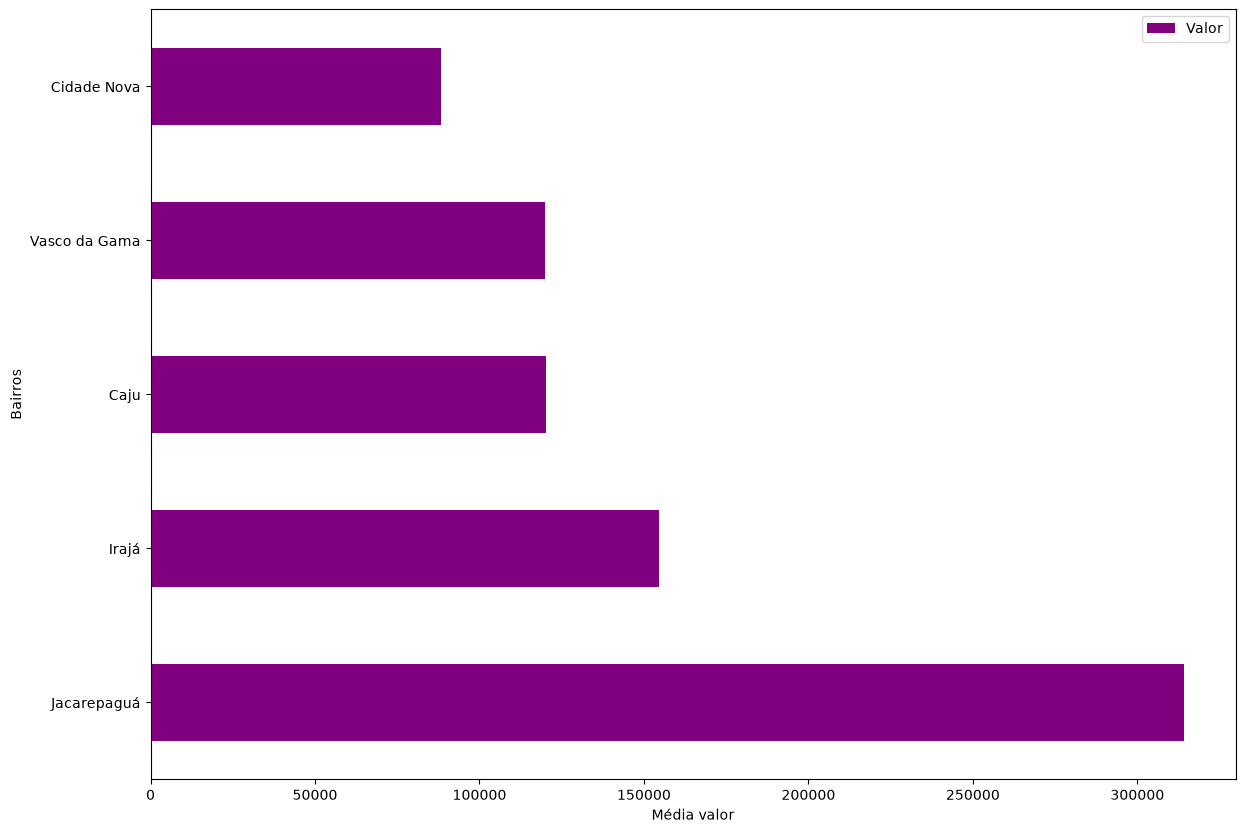

In [69]:
df_bairros.plot(kind='barh', figsize=(14,10), color='purple', ylabel='Bairros', xlabel='Média valor')